# 🧬 01. 탐색적 데이터 분석 (EDA)
> **fertility-predictor** | 난임 환자 임신 성공 여부 예측  
> 데이터: train.csv (256,351행) / test.csv (90,067행) / 68개 컬럼


## 0. 라이브러리 및 설정

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

import platform
if platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
elif platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120

TARGET = '임신 성공 여부'
RANDOM_SEED = 42
print("✅ 라이브러리 로드 완료")

✅ 라이브러리 로드 완료


## 1. 데이터 로드

In [37]:
DATA_DIR = '/Users/admin/Desktop/스트레스 지수 해커톤/open (2)/abc'

train = pd.read_csv(f'{DATA_DIR}/train.csv')
test  = pd.read_csv(f'{DATA_DIR}/test.csv')
sub   = pd.read_csv(f'{DATA_DIR}/sample_submission.csv')

print(f"Train shape : {train.shape}")
print(f"Test  shape : {test.shape}")
print(f"Sub   shape : {sub.shape}")
print()
train.head(3)

Train shape : (256351, 69)
Test  shape : (90067, 68)
Sub   shape : (90067, 2)



,ID,시술 시기 코드,시술 당시 나이,임신 시도 또는 마지막 임신 경과 연수,시술 유형,특정 시술 유형,배란 자극 여부,배란 유도 유형,단일 배아 이식 여부,착상 전 유전 검사 사용 여부,...,기증 배아 사용 여부,대리모 여부,PGD 시술 여부,PGS 시술 여부,난자 채취 경과일,난자 해동 경과일,난자 혼합 경과일,배아 이식 경과일,배아 해동 경과일,임신 성공 여부
0,TRAIN_000000,TRZKPL,만18-34세,NaN,IVF,ICSI,1,기록되지 않은 시행,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,0.0,3.0,NaN,0
1,TRAIN_000001,TRYBLT,만45-50세,NaN,IVF,ICSI,0,알 수 없음,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,0.0,NaN,NaN,0
2,TRAIN_000002,TRVNRY,만18-34세,NaN,IVF,IVF,1,기록되지 않은 시행,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,0.0,2.0,NaN,0


## 2. 기본 정보 및 컬럼 타입

In [38]:
print("=" * 60)
print("컬럼 타입 요약")
print("=" * 60)
print(f"수치형(int/float) : {train.select_dtypes(include=['int64','float64']).shape[1]}개")
print(f"범주형(object)    : {train.select_dtypes(include='object').shape[1]}개")
print()
print(train.dtypes.to_string())

컬럼 타입 요약
수치형(int/float) : 48개
범주형(object)    : 21개

ID                        object
시술 시기 코드                  object
시술 당시 나이                  object
임신 시도 또는 마지막 임신 경과 연수    float64
시술 유형                     object
특정 시술 유형                  object
배란 자극 여부                   int64
배란 유도 유형                  object
단일 배아 이식 여부              float64
착상 전 유전 검사 사용 여부         float64
착상 전 유전 진단 사용 여부         float64
남성 주 불임 원인                 int64
남성 부 불임 원인                 int64
여성 주 불임 원인                 int64
여성 부 불임 원인                 int64
부부 주 불임 원인                 int64
부부 부 불임 원인                 int64
불명확 불임 원인                  int64
불임 원인 - 난관 질환              int64
불임 원인 - 남성 요인              int64
불임 원인 - 배란 장애              int64
불임 원인 - 여성 요인              int64
불임 원인 - 자궁경부 문제            int64
불임 원인 - 자궁내막증              int64
불임 원인 - 정자 농도              int64
불임 원인 - 정자 면역학적 요인         int64
불임 원인 - 정자 운동성             int64
불임 원인 - 정자 형태              int64
배아 생성 주요 이유             

## 3. 타겟 분포 — 클래스 불균형 확인
> 임신 성공(1) vs 실패(0) 비율을 확인합니다. 불균형이 심하면 `scale_pos_weight` 조정 필요.


클래스 분포:
           count  ratio(%)
임신 성공 여부                  
0         190123     74.17
1          66228     25.83

불균형 비율 (실패:성공) = 2.87 : 1


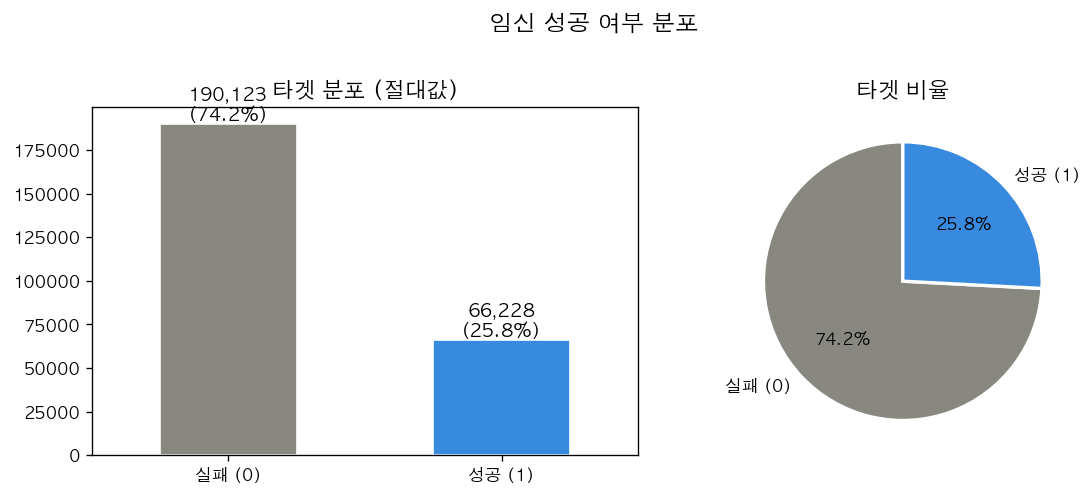

In [39]:
target_counts = train[TARGET].value_counts()
target_ratio  = train[TARGET].value_counts(normalize=True)

print("클래스 분포:")
print(pd.DataFrame({'count': target_counts, 'ratio(%)': (target_ratio * 100).round(2)}))
print(f"\n불균형 비율 (실패:성공) = {target_ratio[0]/target_ratio[1]:.2f} : 1")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

colors = ['#888780', '#378ADD']
target_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='white', width=0.5)
axes[0].set_title('타겟 분포 (절대값)', fontsize=13)
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)
axes[0].set_xticklabels(['실패 (0)', '성공 (1)'])
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():,.0f}\n({p.get_height()/len(train)*100:.1f}%)',
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=11)

axes[1].pie(target_counts, labels=['실패 (0)', '성공 (1)'],
            colors=colors, autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('타겟 비율', fontsize=13)

plt.suptitle('임신 성공 여부 분포', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_target_dist.png', bbox_inches='tight')
plt.show()

## 4. 결측치 분석
> DI(인공수정) 시술 환자의 배아/난자 관련 컬럼 결측은 **정상 결측**입니다. 단순 평균/중앙값으로 채우면 데이터 오염 발생.


[Train] 결측치 있는 컬럼: 31개 / 전체 69개
[Test] 결측치 있는 컬럼: 30개 / 전체 68개


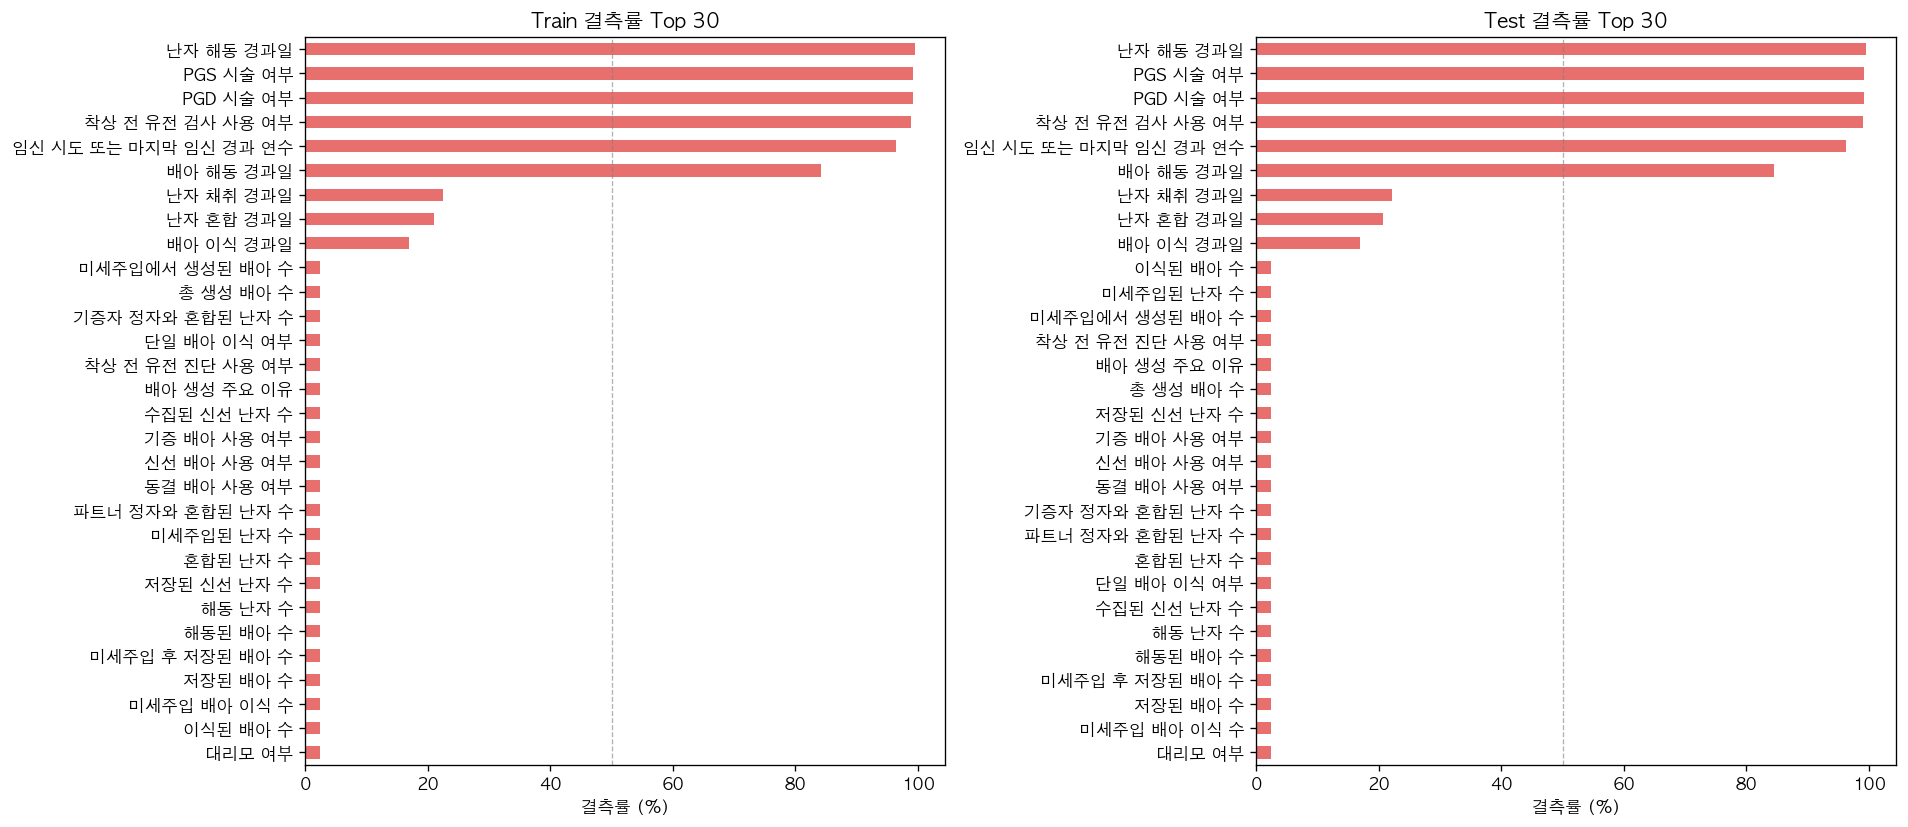


[Train 결측치 Top 20]
                         결측 수  결측률(%)
난자 해동 경과일              254915   99.44
PGS 시술 여부              254422   99.25
PGD 시술 여부              254172   99.15
착상 전 유전 검사 사용 여부       253633   98.94
임신 시도 또는 마지막 임신 경과 연수  246981   96.34
배아 해동 경과일              215982   84.25
난자 채취 경과일               57488   22.43
난자 혼합 경과일               53735   20.96
배아 이식 경과일               43566   16.99
총 생성 배아 수                6291    2.45
기증자 정자와 혼합된 난자 수         6291    2.45
단일 배아 이식 여부              6291    2.45
착상 전 유전 진단 사용 여부         6291    2.45
배아 생성 주요 이유              6291    2.45
대리모 여부                   6291    2.45
기증 배아 사용 여부              6291    2.45
신선 배아 사용 여부              6291    2.45
동결 배아 사용 여부              6291    2.45
파트너 정자와 혼합된 난자 수         6291    2.45
미세주입된 난자 수               6291    2.45


In [40]:
def missing_report(df, name):
    miss     = df.isnull().sum()
    miss     = miss[miss > 0].sort_values(ascending=False)
    miss_pct = (miss / len(df) * 100).round(2)
    report   = pd.DataFrame({'결측 수': miss, '결측률(%)': miss_pct})
    print(f"[{name}] 결측치 있는 컬럼: {len(miss)}개 / 전체 {df.shape[1]}개")
    return report

train_missing = missing_report(train, 'Train')
test_missing  = missing_report(test,  'Test')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, data, title in zip(axes,
                            [train_missing, test_missing],
                            ['Train 결측률 Top 30', 'Test 결측률 Top 30']):
    top = data['결측률(%)'].head(30).sort_values()
    top.plot(kind='barh', ax=ax, color='#E24B4A', alpha=0.8)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('결측률 (%)')
    ax.axvline(50, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)

plt.tight_layout()
plt.savefig('eda_missing.png', bbox_inches='tight')
plt.show()

print("\n[Train 결측치 Top 20]")
print(train_missing.head(20).to_string())

## 5. 컬럼 타입 분류

In [41]:
num_cols = train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = train.select_dtypes(include='object').columns.tolist()

if TARGET in num_cols: num_cols.remove(TARGET)
if TARGET in cat_cols: cat_cols.remove(TARGET)
if 'ID' in num_cols:   num_cols.remove('ID')
if 'ID' in cat_cols:   cat_cols.remove('ID')

print(f"수치형 컬럼 ({len(num_cols)}개):")
for c in num_cols:
    print(f"  - {c}")

print(f"\n범주형 컬럼 ({len(cat_cols)}개):")
for c in cat_cols:
    print(f"  - {c}")

수치형 컬럼 (47개):
  - 임신 시도 또는 마지막 임신 경과 연수
  - 배란 자극 여부
  - 단일 배아 이식 여부
  - 착상 전 유전 검사 사용 여부
  - 착상 전 유전 진단 사용 여부
  - 남성 주 불임 원인
  - 남성 부 불임 원인
  - 여성 주 불임 원인
  - 여성 부 불임 원인
  - 부부 주 불임 원인
  - 부부 부 불임 원인
  - 불명확 불임 원인
  - 불임 원인 - 난관 질환
  - 불임 원인 - 남성 요인
  - 불임 원인 - 배란 장애
  - 불임 원인 - 여성 요인
  - 불임 원인 - 자궁경부 문제
  - 불임 원인 - 자궁내막증
  - 불임 원인 - 정자 농도
  - 불임 원인 - 정자 면역학적 요인
  - 불임 원인 - 정자 운동성
  - 불임 원인 - 정자 형태
  - 총 생성 배아 수
  - 미세주입된 난자 수
  - 미세주입에서 생성된 배아 수
  - 이식된 배아 수
  - 미세주입 배아 이식 수
  - 저장된 배아 수
  - 미세주입 후 저장된 배아 수
  - 해동된 배아 수
  - 해동 난자 수
  - 수집된 신선 난자 수
  - 저장된 신선 난자 수
  - 혼합된 난자 수
  - 파트너 정자와 혼합된 난자 수
  - 기증자 정자와 혼합된 난자 수
  - 동결 배아 사용 여부
  - 신선 배아 사용 여부
  - 기증 배아 사용 여부
  - 대리모 여부
  - PGD 시술 여부
  - PGS 시술 여부
  - 난자 채취 경과일
  - 난자 해동 경과일
  - 난자 혼합 경과일
  - 배아 이식 경과일
  - 배아 해동 경과일

범주형 컬럼 (20개):
  - 시술 시기 코드
  - 시술 당시 나이
  - 시술 유형
  - 특정 시술 유형
  - 배란 유도 유형
  - 배아 생성 주요 이유
  - 총 시술 횟수
  - 클리닉 내 총 시술 횟수
  - IVF 시술 횟수
  - DI 시술 횟수
  - 총 임신 횟수
  - IVF 임신 횟수
  - DI 임신 횟수
  - 총 출산 횟수
  - IVF 출산 횟수
 

## 6. 범주형 컬럼 분석
> 각 범주형 컬럼의 고유값 수와 임신 성공률을 확인합니다.


In [42]:
print(f"{'컬럼명':<30} {'고유값 수':>8}  Top3 값")
print("-" * 70)
for col in cat_cols:
    uniq = train[col].nunique()
    top3 = train[col].value_counts().head(3).index.tolist()
    print(f"{col:<30} {uniq:>8}  {top3}")

컬럼명                               고유값 수  Top3 값
----------------------------------------------------------------------
시술 시기 코드                              7  ['TRDQAZ', 'TRCMWS', 'TRYBLT']
시술 당시 나이                              7  ['만18-34세', '만35-37세', '만38-39세']
시술 유형                                 2  ['IVF', 'DI']
특정 시술 유형                             24  ['ICSI', 'IVF', 'Unknown']
배란 유도 유형                              4  ['기록되지 않은 시행', '알 수 없음', '세트로타이드 (억제제)']
배아 생성 주요 이유                          13  ['현재 시술용', '배아 저장용', '기증용, 현재 시술용']
총 시술 횟수                               7  ['0회', '1회', '2회']
클리닉 내 총 시술 횟수                         7  ['0회', '1회', '2회']
IVF 시술 횟수                             7  ['0회', '1회', '2회']
DI 시술 횟수                              7  ['0회', '3회', '2회']
총 임신 횟수                               7  ['0회', '1회', '2회']
IVF 임신 횟수                             7  ['0회', '1회', '2회']
DI 임신 횟수                              6  ['0회', '1회', '2회']
총 출산 횟수                         

### 6-1. 주요 범주형 컬럼 × 임신 성공률

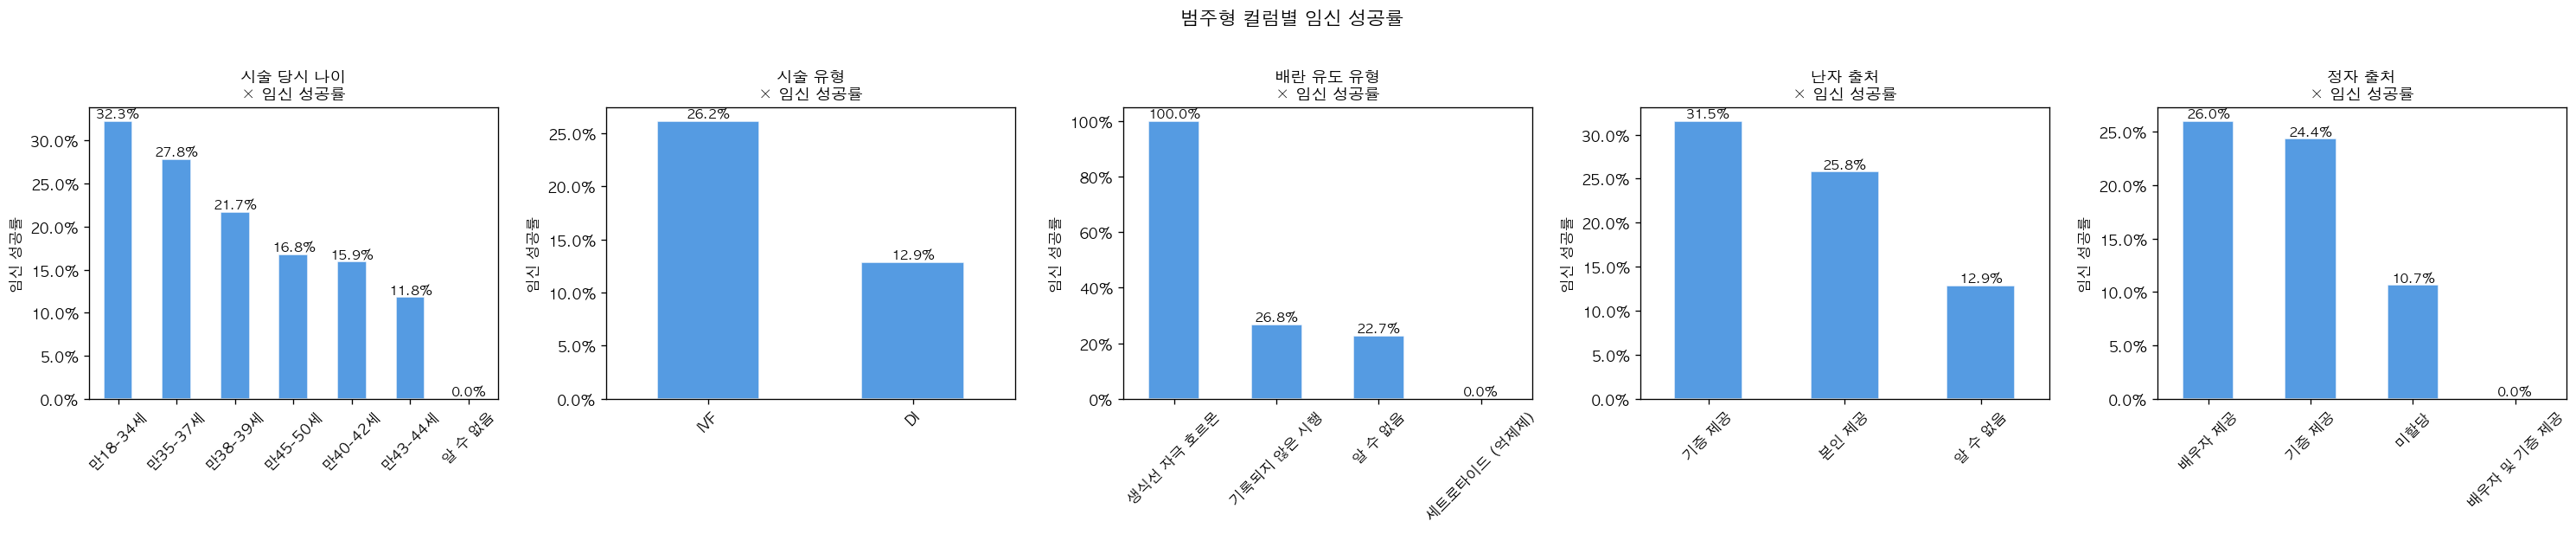

In [43]:
key_cat_cols = ['시술 당시 나이', '시술 유형', '배란 유도 유형', '난자 출처', '정자 출처']
key_cat_cols = [c for c in key_cat_cols if c in train.columns]

n = len(key_cat_cols)
fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))
if n == 1:
    axes = [axes]

for ax, col in zip(axes, key_cat_cols):
    success_rate = train.groupby(col)[TARGET].mean().sort_values(ascending=False)
    success_rate.plot(kind='bar', ax=ax, color='#378ADD', alpha=0.85, edgecolor='white')
    ax.set_title(f'{col}\n× 임신 성공률', fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel('임신 성공률')
    ax.tick_params(axis='x', rotation=45)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1%}',
                    (p.get_x() + p.get_width()/2, p.get_height()),
                    ha='center', va='bottom', fontsize=9)

plt.suptitle('범주형 컬럼별 임신 성공률', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_cat_success_rate.png', bbox_inches='tight')
plt.show()

## 7. 수치형 컬럼 분석
### 7-1. 기술통계


In [44]:
train[num_cols].describe().T.style.background_gradient(cmap='Blues', axis=1)

,count,mean,std,min,25%,50%,75%,max
임신 시도 또는 마지막 임신 경과 연수,9370.000000,9.270651,3.550313,0.000000,7.000000,9.000000,11.000000,20.000000
배란 자극 여부,256351.000000,0.771286,0.420005,0.000000,1.000000,1.000000,1.000000,1.000000
단일 배아 이식 여부,250060.000000,0.233476,0.423043,0.000000,0.000000,0.000000,0.000000,1.000000
착상 전 유전 검사 사용 여부,2718.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
착상 전 유전 진단 사용 여부,250060.000000,0.012781,0.112328,0.000000,0.000000,0.000000,0.000000,1.000000
남성 주 불임 원인,256351.000000,0.028516,0.166441,0.000000,0.000000,0.000000,0.000000,1.000000
남성 부 불임 원인,256351.000000,0.013115,0.113767,0.000000,0.000000,0.000000,0.000000,1.000000
여성 주 불임 원인,256351.000000,0.030724,0.172568,0.000000,0.000000,0.000000,0.000000,1.000000
여성 부 불임 원인,256351.000000,0.012432,0.110805,0.000000,0.000000,0.000000,0.000000,1.000000
부부 주 불임 원인,256351.000000,0.033068,0.178814,0.000000,0.000000,0.000000,0.000000,1.000000


### 7-2. 수치형 컬럼 분포 (성공 vs 실패 비교)

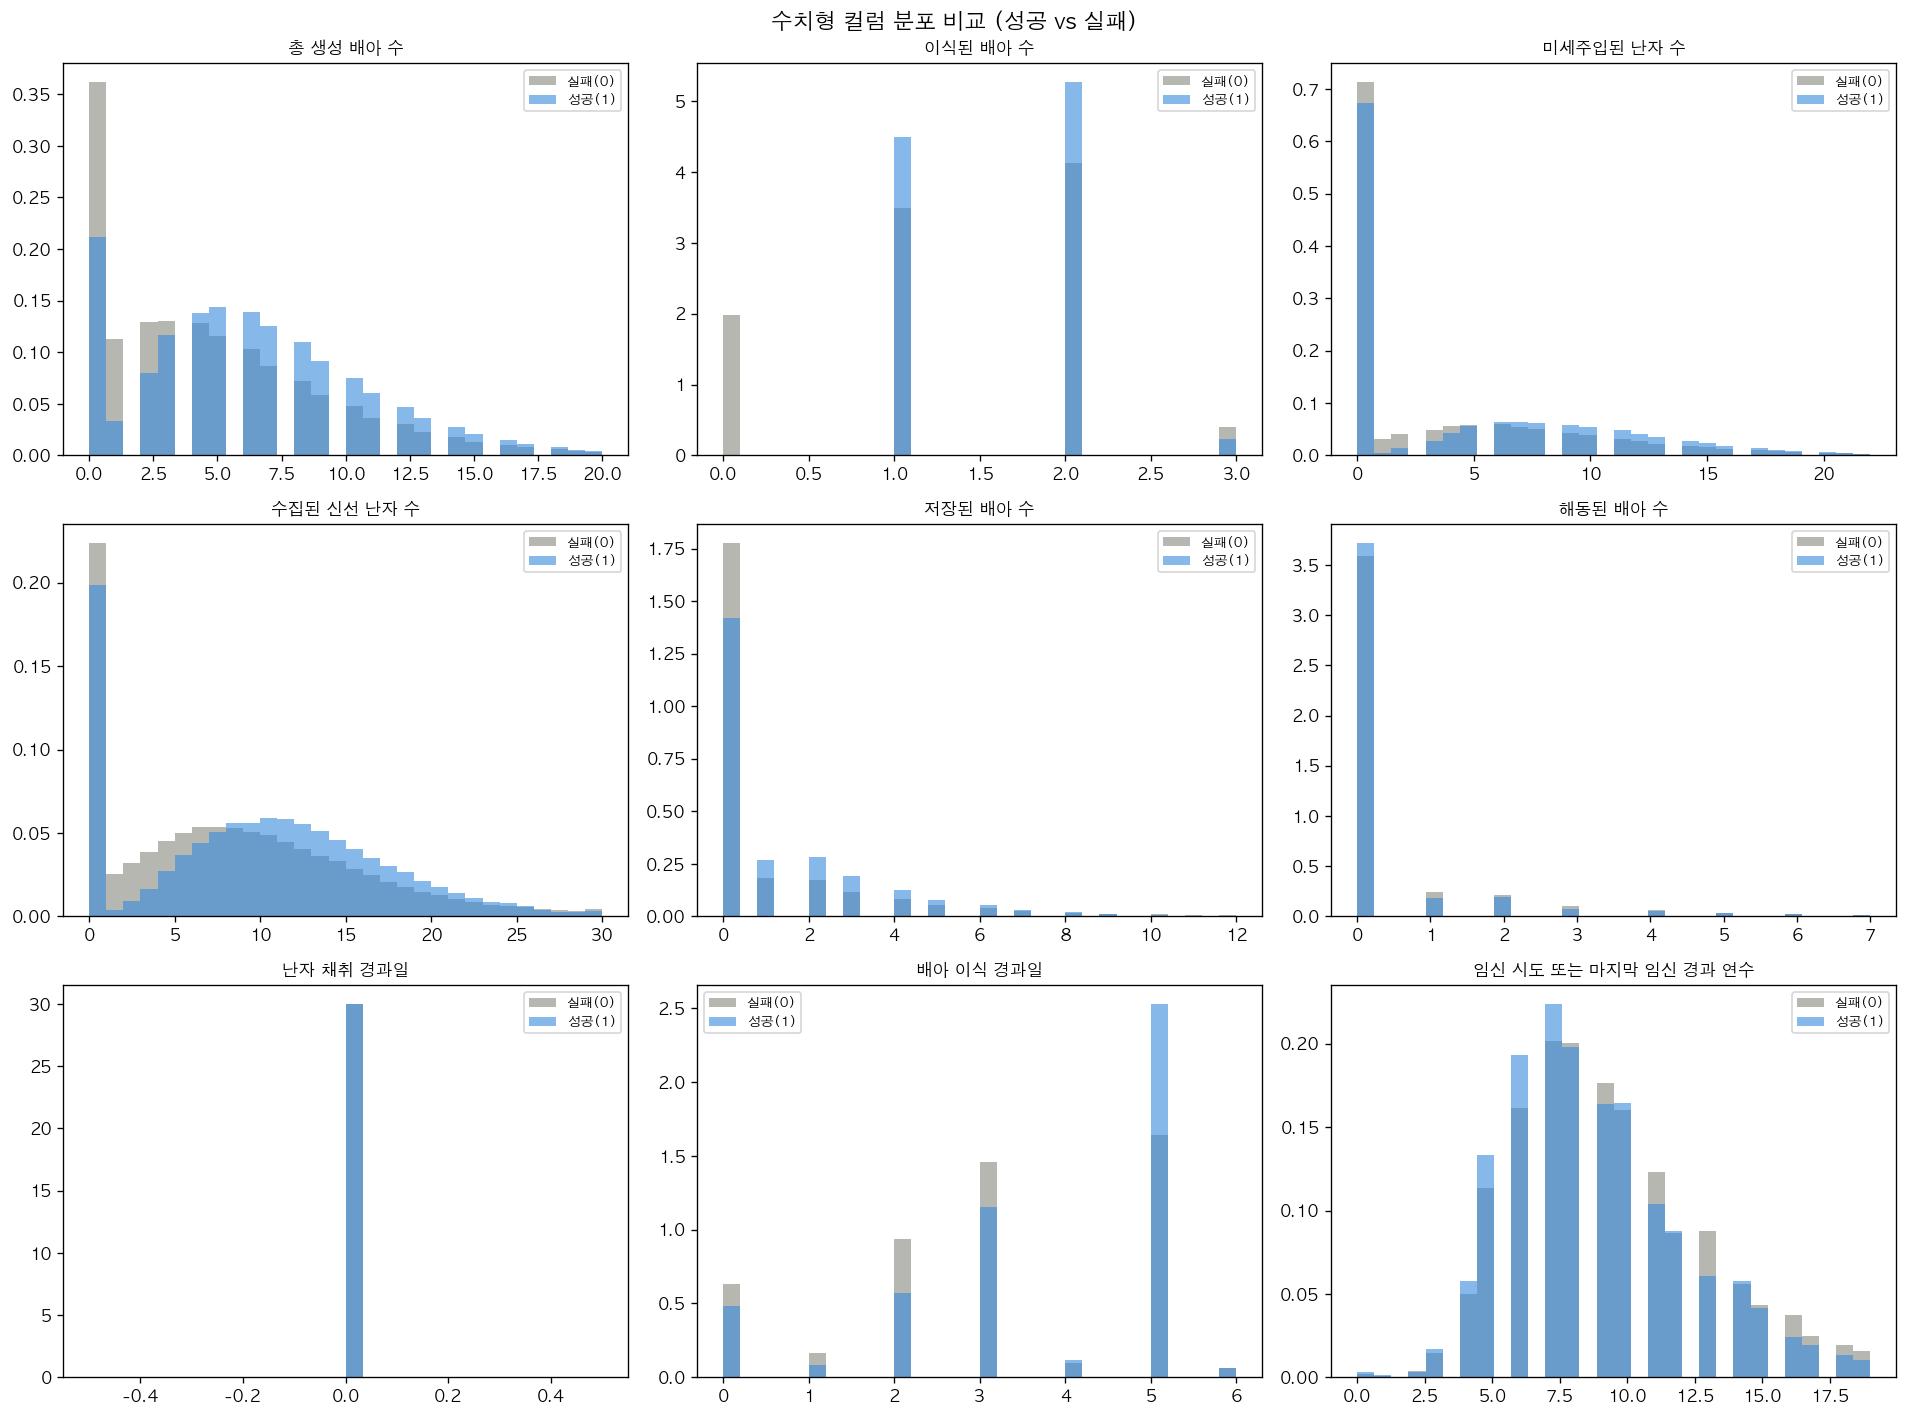

In [45]:
key_num_cols = [
    '총 생성 배아 수', '이식된 배아 수', '미세주입된 난자 수',
    '수집된 신선 난자 수', '저장된 배아 수', '해동된 배아 수',
    '난자 채취 경과일', '배아 이식 경과일', '임신 시도 또는 마지막 임신 경과 연수'
]
key_num_cols = [c for c in key_num_cols if c in train.columns]

n_cols = 3
n_rows = (len(key_num_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

success = train[train[TARGET] == 1]
failure = train[train[TARGET] == 0]

for i, col in enumerate(key_num_cols):
    ax = axes[i]
    q99 = train[col].quantile(0.99)
    data_s = success[col].dropna()
    data_f = failure[col].dropna()
    data_s = data_s[data_s <= q99]
    data_f = data_f[data_f <= q99]

    ax.hist(data_f, bins=30, alpha=0.6, color='#888780', label='실패(0)', density=True)
    ax.hist(data_s, bins=30, alpha=0.6, color='#378ADD', label='성공(1)', density=True)
    ax.set_title(col, fontsize=10)
    ax.legend(fontsize=8)
    ax.set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('수치형 컬럼 분포 비교 (성공 vs 실패)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_num_dist.png', bbox_inches='tight')
plt.show()

## 8. 타겟과 수치형 컬럼 상관관계
> 절대값 기준 상위 컬럼이 피처 선택의 힌트가 됩니다.


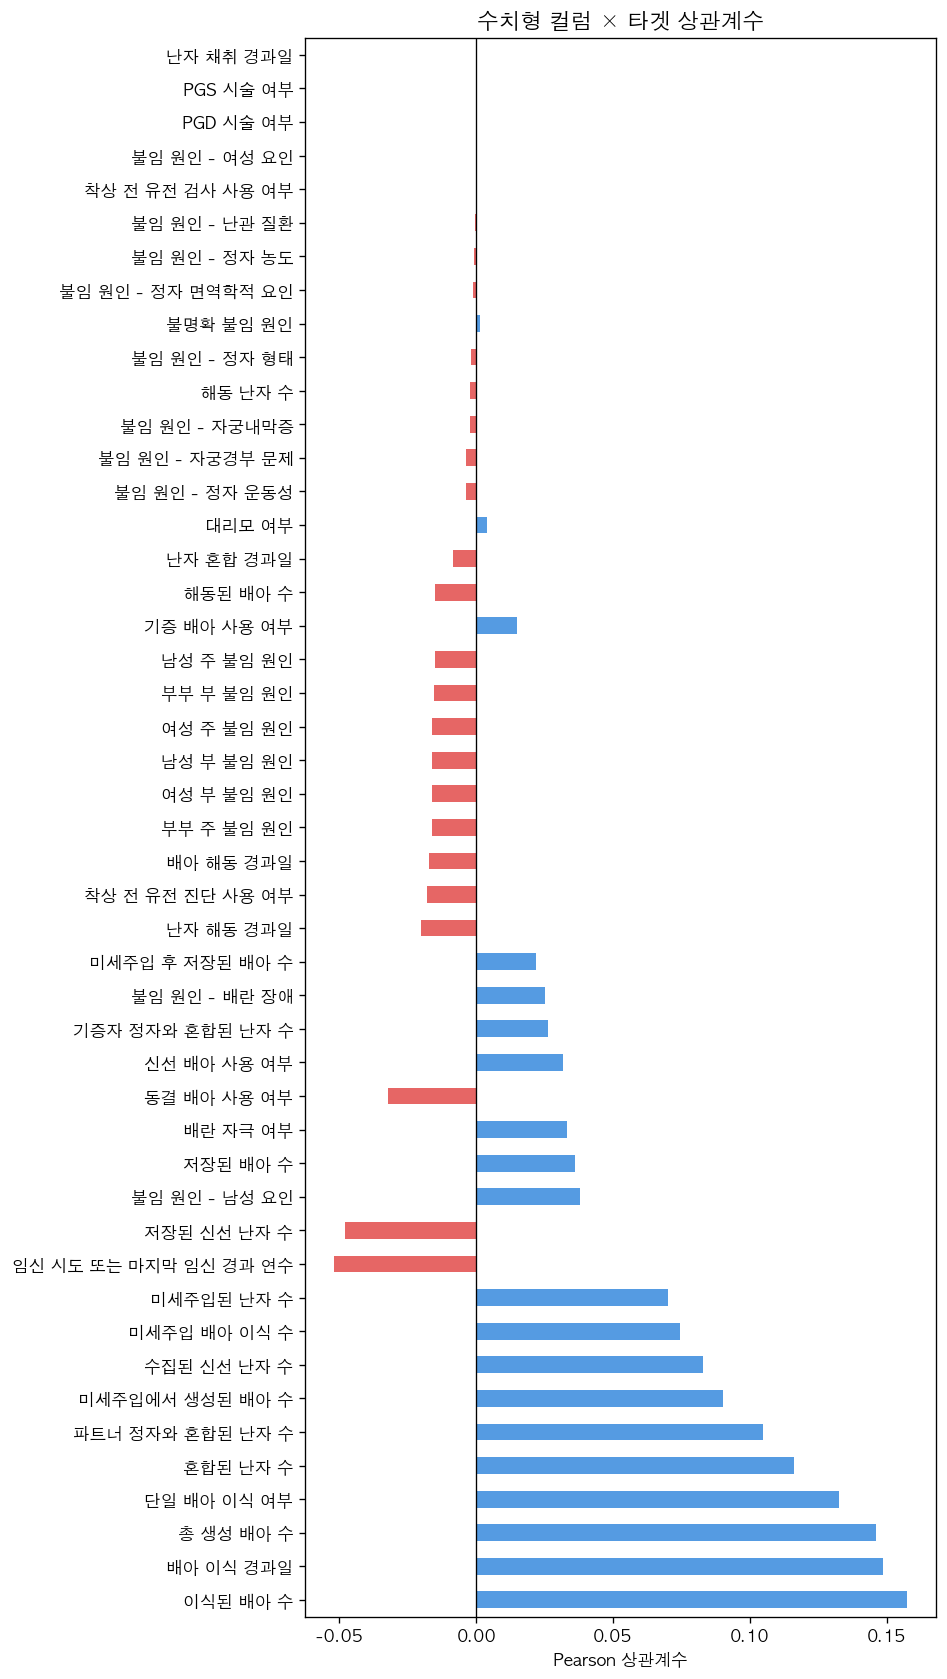


[상위 15개]
이식된 배아 수                 0.157487
배아 이식 경과일                0.148590
총 생성 배아 수                0.146116
단일 배아 이식 여부              0.132635
혼합된 난자 수                 0.116136
파트너 정자와 혼합된 난자 수         0.104902
미세주입에서 생성된 배아 수          0.090275
수집된 신선 난자 수              0.083023
미세주입 배아 이식 수             0.074351
미세주입된 난자 수               0.070117
임신 시도 또는 마지막 임신 경과 연수   -0.051925
저장된 신선 난자 수             -0.047763
불임 원인 - 남성 요인            0.037908
저장된 배아 수                 0.036024
배란 자극 여부                 0.033212


In [46]:
corr = train[num_cols + [TARGET]].corr()[TARGET].drop(TARGET)
corr_sorted = corr.reindex(corr.abs().sort_values(ascending=False).index)

fig, ax = plt.subplots(figsize=(8, max(6, len(corr_sorted) * 0.3)))
colors = ['#378ADD' if v > 0 else '#E24B4A' for v in corr_sorted]
corr_sorted.plot(kind='barh', ax=ax, color=colors, alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('수치형 컬럼 × 타겟 상관계수', fontsize=13)
ax.set_xlabel('Pearson 상관계수')

plt.tight_layout()
plt.savefig('eda_corr.png', bbox_inches='tight')
plt.show()

print("\n[상위 15개]")
print(corr_sorted.head(15).to_string())

## 9. 불임 원인 컬럼 분석 (17개)
> 불임 원인 컬럼은 모두 이진(0/1) 변수입니다. 각 원인별 임신 성공률을 비교합니다.


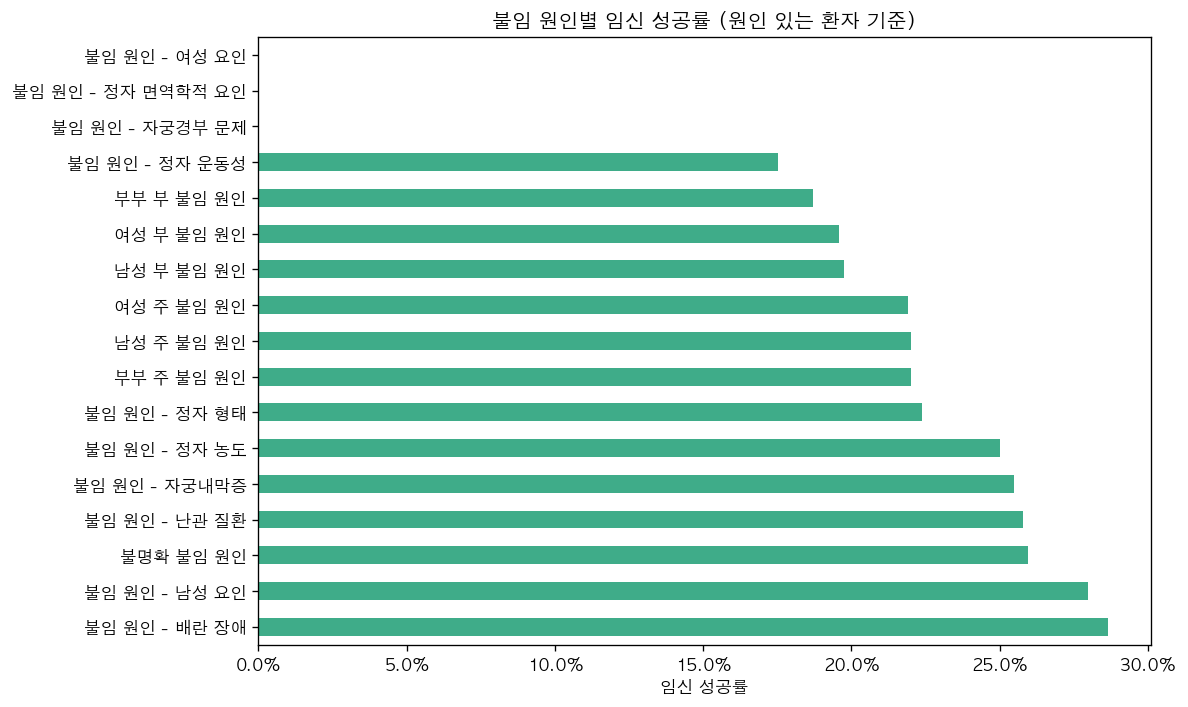

In [47]:
infertility_cols = [c for c in train.columns if '불임 원인' in c or
                    c in ['남성 주 불임 원인', '남성 부 불임 원인',
                           '여성 주 불임 원인', '여성 부 불임 원인',
                           '부부 주 불임 원인', '부부 부 불임 원인',
                           '불명확 불임 원인']]

if infertility_cols:
    success_by_cause = {}
    for col in infertility_cols:
        rate = train[train[col] == 1][TARGET].mean()
        success_by_cause[col] = rate

    cause_df = pd.Series(success_by_cause).sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(10, 6))
    cause_df.plot(kind='barh', ax=ax, color='#1D9E75', alpha=0.85)
    ax.set_title('불임 원인별 임신 성공률 (원인 있는 환자 기준)', fontsize=12)
    ax.set_xlabel('임신 성공률')
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))

    plt.tight_layout()
    plt.savefig('eda_infertility_cause.png', bbox_inches='tight')
    plt.show()
else:
    print("불임 원인 컬럼을 찾지 못했습니다. 컬럼명을 확인하세요.")

## 10. 시술 유형별 분석
> IVF vs DI 시술 경로에 따라 결측 패턴이 완전히 다릅니다. 모델링 전 그룹 분리 필수.


In [48]:
if '시술 유형' in train.columns:
    print("=== 시술 유형 분포 ===")
    print(train['시술 유형'].value_counts())
    print()

    for stype in train['시술 유형'].unique():
        sub_df = train[train['시술 유형'] == stype]
        rate   = sub_df[TARGET].mean()
        print(f"[{stype}] 총 {len(sub_df):,}건 | 임신 성공률: {rate:.2%}")

=== 시술 유형 분포 ===
시술 유형
IVF    250060
DI       6291
Name: count, dtype: int64

[IVF] 총 250,060건 | 임신 성공률: 26.16%
[DI] 총 6,291건 | 임신 성공률: 12.89%


### 10-1. 특정 시술 유형 파싱 (멀티핫 인코딩 미리보기)

In [49]:
if '특정 시술 유형' in train.columns:
    print("=== 특정 시술 유형 Top 20 ===")
    print(train['특정 시술 유형'].value_counts().head(20))
    print()

    keywords = ['IVF', 'ICSI', 'IUI', 'ICI', 'FER', 'BLASTOCYST', 'AH', 'GIFT', 'IVI']
    print("=== 키워드별 등장 횟수 및 임신 성공률 ===")
    print(f"{'키워드':<15} {'등장 건수':>10}  {'임신 성공률':>10}")
    print("-" * 40)
    for kw in keywords:
        mask = train['특정 시술 유형'].str.contains(kw, na=False)
        count = mask.sum()
        if count > 0:
            rate = train[mask][TARGET].mean()
            print(f"{kw:<15} {count:>10,}  {rate:>10.2%}")

=== 특정 시술 유형 Top 20 ===
특정 시술 유형
ICSI                                   122368
IVF                                     91755
Unknown                                 26939
IUI                                      6100
ICSI:ICSI                                2314
ICSI / BLASTOCYST                        1609
IVF / BLASTOCYST                         1248
IVF:IVF                                  1146
ICSI:IVF                                  873
ICSI / AH                                 769
IVF:ICSI                                  392
IVF / AH                                  319
ICSI:Unknown                              207
IVF:Unknown                               100
ICI                                        96
Generic DI                                 71
IVI                                        23
ICSI / BLASTOCYST:IVF / BLASTOCYST          6
ICSI / BLASTOCYST :IVF / BLASTOCYST         4
FER                                         3
Name: count, dtype: int64

=== 키워드별 등장 횟수 및 임신 

## 11. 경과일 컬럼 분석
> 경과일 간 차이(배양 기간 등)로 파생 피처를 만들 수 있습니다.


경과일 컬럼 (5개): ['난자 채취 경과일', '난자 해동 경과일', '난자 혼합 경과일', '배아 이식 경과일', '배아 해동 경과일']

              count      mean       std  min  25%  50%  75%  max
난자 채취 경과일  198863.0  0.000000  0.000000  0.0  0.0  0.0  0.0  0.0
난자 해동 경과일    1436.0  0.001393  0.037307  0.0  0.0  0.0  0.0  1.0
난자 혼합 경과일  202616.0  0.005385  0.111504  0.0  0.0  0.0  0.0  7.0
배아 이식 경과일  212785.0  3.254741  1.715697  0.0  2.0  3.0  5.0  7.0
배아 해동 경과일   40369.0  0.045629  0.418672  0.0  0.0  0.0  0.0  7.0

=== 배양 기간 (이식 경과일 - 혼합 경과일) ===
count    175808.000000
mean          3.795720
std           1.254418
min          -5.000000
25%           3.000000
50%           3.000000
75%           5.000000
max           7.000000
Name: _배양기간, dtype: float64



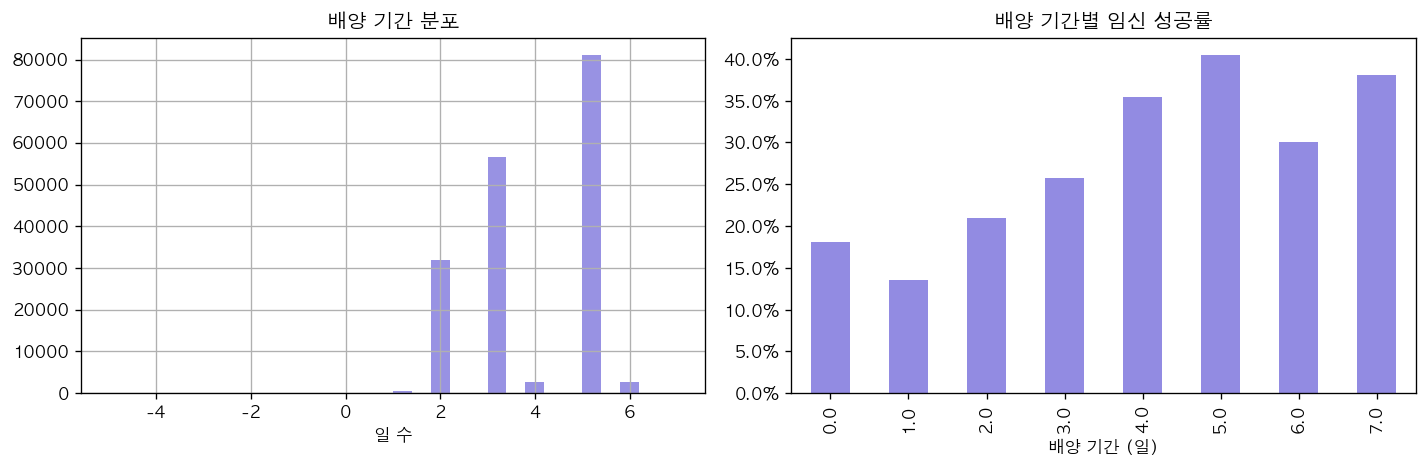

In [50]:
elapsed_cols = [c for c in train.columns if '경과일' in c]
print(f"경과일 컬럼 ({len(elapsed_cols)}개): {elapsed_cols}")
print()

if elapsed_cols:
    print(train[elapsed_cols].describe().T.to_string())
    print()

    if '배아 이식 경과일' in train.columns and '난자 혼합 경과일' in train.columns:
        train['_배양기간'] = train['배아 이식 경과일'] - train['난자 혼합 경과일']
        print("=== 배양 기간 (이식 경과일 - 혼합 경과일) ===")
        print(train['_배양기간'].describe())
        print()

        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        train['_배양기간'].hist(bins=30, ax=axes[0], color='#7F77DD', alpha=0.8)
        axes[0].set_title('배양 기간 분포')
        axes[0].set_xlabel('일 수')

        rate_by_culture = train.groupby('_배양기간')[TARGET].mean()
        mask = (rate_by_culture.index >= 0) & (rate_by_culture.index <= 10)
        rate_by_culture[mask].plot(
            kind='bar', ax=axes[1], color='#7F77DD', alpha=0.85
        )
        axes[1].set_title('배양 기간별 임신 성공률')
        axes[1].set_xlabel('배양 기간 (일)')
        axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

        plt.tight_layout()
        plt.savefig('eda_culture_days.png', bbox_inches='tight')
        plt.show()

        train.drop(columns=['_배양기간'], inplace=True)

## 12. Train / Test 컬럼 일치 확인 및 EDA 요약

In [51]:
train_cols = set(train.columns)
test_cols  = set(test.columns)

only_train = train_cols - test_cols - {TARGET}
only_test  = test_cols - train_cols

print(f"Train에만 있는 컬럼: {only_train}")
print(f"Test에만 있는 컬럼:  {only_test}")
print()
print("✅ 컬럼 일치 확인 완료" if not only_train and not only_test else "⚠️ 컬럼 불일치 — 확인 필요")

Train에만 있는 컬럼: set()
Test에만 있는 컬럼:  set()

✅ 컬럼 일치 확인 완료


## ✅ EDA 요약 및 다음 단계

| 항목 | 확인 내용 | 조치 방향 |
|------|----------|----------|
| 클래스 불균형 | 임신 성공 비율 확인 | `scale_pos_weight` 조정 |
| 구조적 결측치 | DI 시술 배아 컬럼 결측 = 정상 | 시술 유형별 분리 처리 |
| 특정 시술 유형 | `/`, `:` 복합 문자열 | 멀티핫 인코딩 |
| 경과일 파생 | 배양기간 = 이식 - 혼합 경과일 | 5일↑ = 배반포 지표 |
| 시술 이력 컬럼 | 0회~6회 이상 문자열 | 수치 변환 후 인코딩 |

### 👉 다음 단계: `02_preprocessing.ipynb`
- 컬럼 타입별 인코딩
- 구조적 결측치 처리
- 파생 피처 생성
- Train/Test 동일 전처리 적용
